#PARTIE 1 — Importation des bibliothèques

In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from scipy import stats
from scipy.stats import f_oneway, kruskal
import warnings
warnings.filterwarnings('ignore')
import os
import json
import gradio as gr
from getpass import getpass
from openai import OpenAI

os.environ["OPENAI_API_KEY"] = getpass("Entre ta clé API OpenAI : ")
client = OpenAI(api_key=os.environ["OPENAI_API_KEY"])

Entre ta clé API OpenAI : ··········


#PARTIE 2 — Chargement des données

In [15]:
df = pd.read_csv('/content/train.zip', parse_dates=['pickup_datetime', 'dropoff_datetime'], encoding='latin1')

print("Dimensions du dataset :", df.shape)
df.head()

Dimensions du dataset : (1458644, 11)


,id,vendor_id,pickup_datetime,dropoff_datetime,passenger_count,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,store_and_fwd_flag,trip_duration
0,id2875421,2,2016-03-14 17:24:55,2016-03-14 17:32:30,1,-73.982155,40.767937,-73.964630,40.765602,N,455
1,id2377394,1,2016-06-12 00:43:35,2016-06-12 00:54:38,1,-73.980415,40.738564,-73.999481,40.731152,N,663
2,id3858529,2,2016-01-19 11:35:24,2016-01-19 12:10:48,1,-73.979027,40.763939,-74.005333,40.710087,N,2124
3,id3504673,2,2016-04-06 19:32:31,2016-04-06 19:39:40,1,-74.010040,40.719971,-74.012268,40.706718,N,429
4,id2181028,2,2016-03-26 13:30:55,2016-03-26 13:38:10,1,-73.973053,40.793209,-73.972923,40.782520,N,435


#**PARTIE 3 — Traitement des données**

In [16]:
print("Valeurs manquantes :")
print(df.isnull().sum())

cols_essentielles = [
    'pickup_datetime', 'dropoff_datetime', 'trip_duration',
    'pickup_longitude', 'pickup_latitude',
    'dropoff_longitude', 'dropoff_latitude',
    'passenger_count'
]

df = df.dropna(subset=cols_essentielles)
df = df.drop_duplicates()

df = df[(df['trip_duration'] >= 60) & (df['trip_duration'] <= 7200)]

df = df[
    (df['pickup_longitude'].between(-74.05, -73.75)) &
    (df['pickup_latitude'].between(40.60, 40.90)) &
    (df['dropoff_longitude'].between(-74.05, -73.75)) &
    (df['dropoff_latitude'].between(40.60, 40.90))
]

df = df[(df['passenger_count'] >= 1) & (df['passenger_count'] <= 6)]
df = df.reset_index(drop=True)

print("Dimensions après traitement :", df.shape)

Valeurs manquantes :
id                    0
vendor_id             0
pickup_datetime       0
dropoff_datetime      0
passenger_count       0
pickup_longitude      0
pickup_latitude       0
dropoff_longitude     0
dropoff_latitude      0
store_and_fwd_flag    0
trip_duration         0
dtype: int64
Dimensions après traitement : (1440874, 11)


#**PARTIE 4 — Feature engineering**

In [17]:
# Variables temporelles
df['hour'] = df['pickup_datetime'].dt.hour
df['day_of_week'] = df['pickup_datetime'].dt.dayofweek
df['day_name'] = df['pickup_datetime'].dt.day_name()
df['month'] = df['pickup_datetime'].dt.month
df['is_weekend'] = df['day_of_week'].isin([5, 6]).astype(int)

# Périodes de la journée
def get_period(h):
    if 0 <= h < 6:
        return 'Nuit'
    elif 6 <= h < 9:
        return 'Matin'
    elif 9 <= h < 12:
        return 'Matinée'
    elif 12 <= h < 14:
        return 'Midi'
    elif 14 <= h < 17:
        return 'Après-midi'
    elif 17 <= h < 20:
        return 'Soirée'
    else:
        return 'Nuit tardive'

df['period'] = df['hour'].apply(get_period)

# Distance Haversine
def haversine(lat1, lon1, lat2, lon2):
    R = 6371
    lat1, lon1, lat2, lon2 = map(np.radians, [lat1, lon1, lat2, lon2])
    dlat = lat2 - lat1
    dlon = lon2 - lon1
    a = np.sin(dlat/2)**2 + np.cos(lat1)*np.cos(lat2)*np.sin(dlon/2)**2
    return R * 2 * np.arcsin(np.sqrt(a))

df['distance_km'] = haversine(
    df['pickup_latitude'], df['pickup_longitude'],
    df['dropoff_latitude'], df['dropoff_longitude']
)

df['duration_min'] = df['trip_duration'] / 60
df['speed_kmh'] = np.where(
    df['duration_min'] > 0,
    df['distance_km'] / (df['duration_min'] / 60),
    0
)

df = df[(df['speed_kmh'] > 0) & (df['speed_kmh'] < 120)].copy()

print("Feature engineering terminé")
df[['hour', 'period', 'distance_km', 'duration_min', 'speed_kmh']].head()

Feature engineering terminé


,hour,period,distance_km,duration_min,speed_kmh
0,17,Soirée,1.498521,7.583333,11.856428
1,0,Nuit,1.805507,11.050000,9.803659
2,11,Matinée,6.385098,35.400000,10.822201
3,19,Soirée,1.485498,7.150000,12.465721
4,13,Midi,1.188588,7.250000,9.836594


# **PARTIE 5 — EDA**


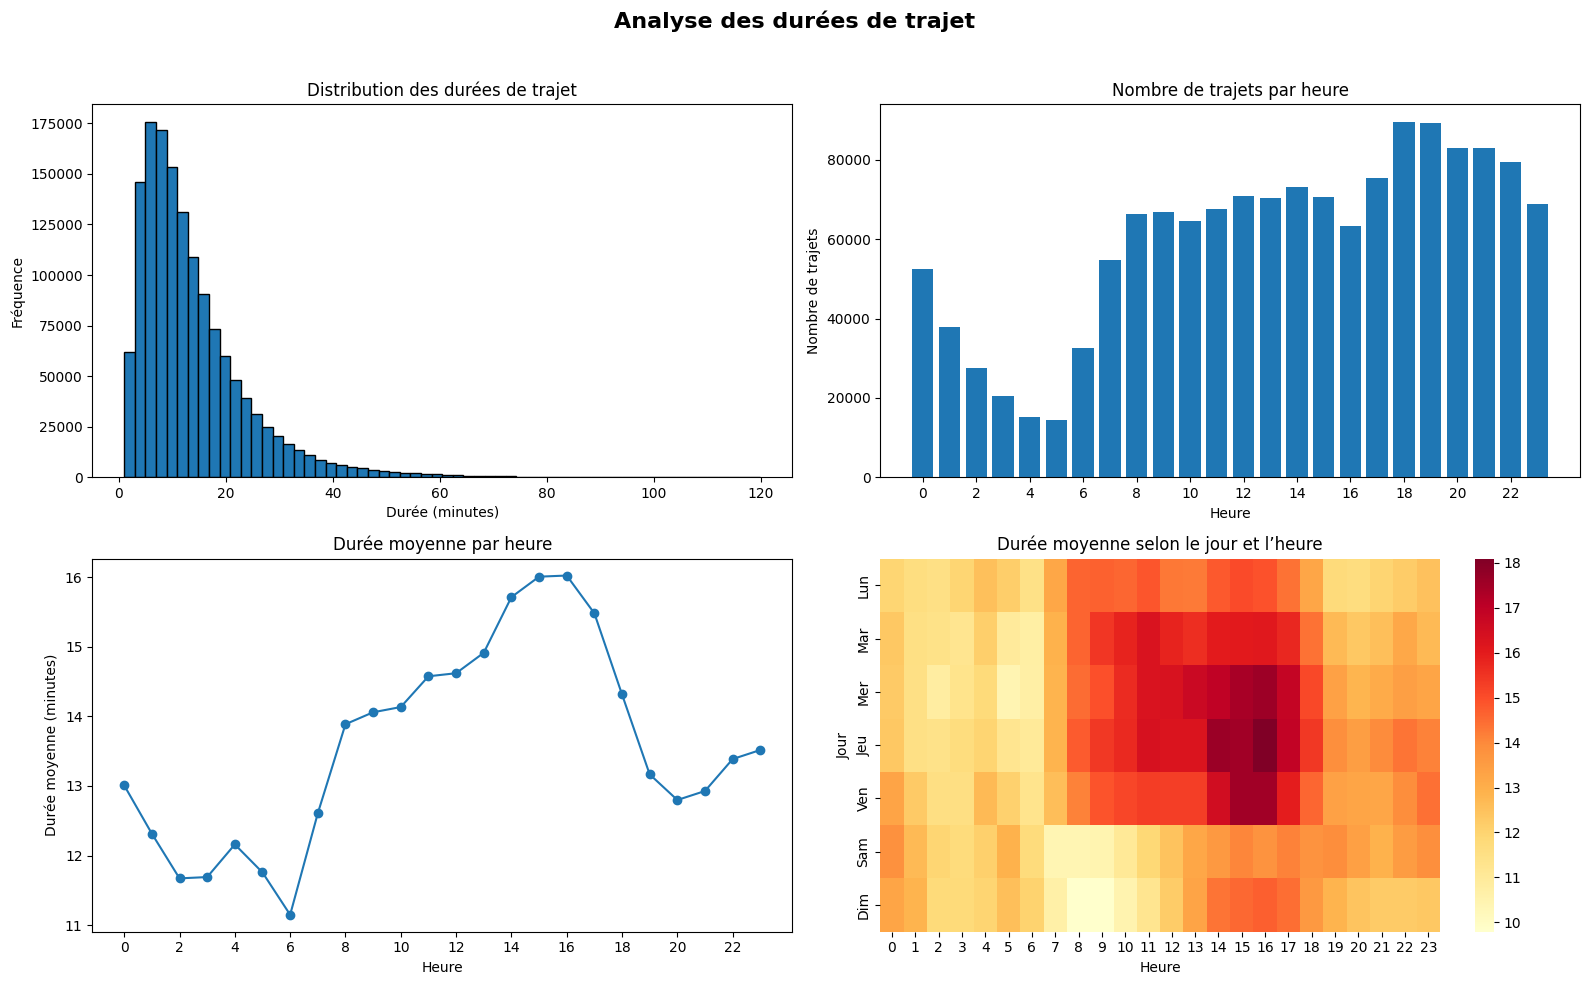

In [18]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle("Analyse des durées de trajet", fontsize=16, fontweight='bold')

# 1. Distribution des durées
axes[0, 0].hist(df['duration_min'], bins=60, edgecolor='black')
axes[0, 0].set_title('Distribution des durées de trajet')
axes[0, 0].set_xlabel('Durée (minutes)')
axes[0, 0].set_ylabel('Fréquence')

# 2. Nombre de trajets par heure
hourly_counts = df['hour'].value_counts().sort_index()
axes[0, 1].bar(hourly_counts.index, hourly_counts.values)
axes[0, 1].set_title('Nombre de trajets par heure')
axes[0, 1].set_xlabel('Heure')
axes[0, 1].set_ylabel('Nombre de trajets')
axes[0, 1].set_xticks(range(0, 24, 2))

# 3. Durée moyenne par heure
hourly_mean = df.groupby('hour')['duration_min'].mean()
axes[1, 0].plot(hourly_mean.index, hourly_mean.values, marker='o')
axes[1, 0].set_title('Durée moyenne par heure')
axes[1, 0].set_xlabel('Heure')
axes[1, 0].set_ylabel('Durée moyenne (minutes)')
axes[1, 0].set_xticks(range(0, 24, 2))

# 4. Heatmap jour × heure
pivot = df.pivot_table(values='duration_min', index='day_of_week', columns='hour', aggfunc='mean')
pivot.index = ['Lun', 'Mar', 'Mer', 'Jeu', 'Ven', 'Sam', 'Dim']

sns.heatmap(pivot, cmap='YlOrRd', ax=axes[1, 1])
axes[1, 1].set_title('Durée moyenne selon le jour et l’heure')
axes[1, 1].set_xlabel('Heure')
axes[1, 1].set_ylabel('Jour')

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

# **PARTIE 6 - Test : ANOVA**

Résultat ANOVA
F-statistic = 2600.03
p-value = 0.00000
Les durées varient significativement selon les périodes de la journée.
Eta carré = 0.0107
Kruskal-Wallis : H = 10604.77, p-value = 0.00000


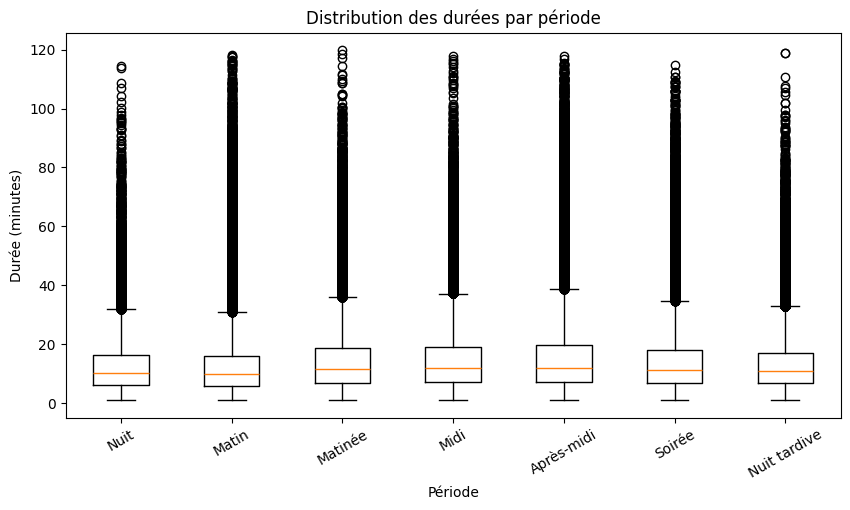

In [19]:
period_order = ['Nuit', 'Matin', 'Matinée', 'Midi', 'Après-midi', 'Soirée', 'Nuit tardive']
groups = [df[df['period'] == p]['duration_min'].values for p in period_order]

f_stat, p_value = f_oneway(*groups)

print("Résultat ANOVA")
print(f"F-statistic = {f_stat:.2f}")
print(f"p-value = {p_value:.5f}")

if p_value < 0.05:
    print("Les durées varient significativement selon les périodes de la journée.")
else:
    print("Pas de différence significative entre les périodes.")

# Taille d’effet
grand_mean = df['duration_min'].mean()
ss_between = sum(len(g) * (g.mean() - grand_mean)**2 for g in groups)
ss_total = sum((df['duration_min'] - grand_mean)**2)
eta2 = ss_between / ss_total

print(f"Eta carré = {eta2:.4f}")

# Test de confirmation
h_stat, p_kw = kruskal(*groups)
print(f"Kruskal-Wallis : H = {h_stat:.2f}, p-value = {p_kw:.5f}")

# Boxplot par période
data_plot = [df[df['period'] == p]['duration_min'] for p in period_order]

plt.figure(figsize=(10,5))
plt.boxplot(data_plot, labels=period_order)
plt.title('Distribution des durées par période')
plt.xlabel('Période')
plt.ylabel('Durée (minutes)')
plt.xticks(rotation=30)
plt.show()

# **PARTIE 7 - Visualisation temporelle**

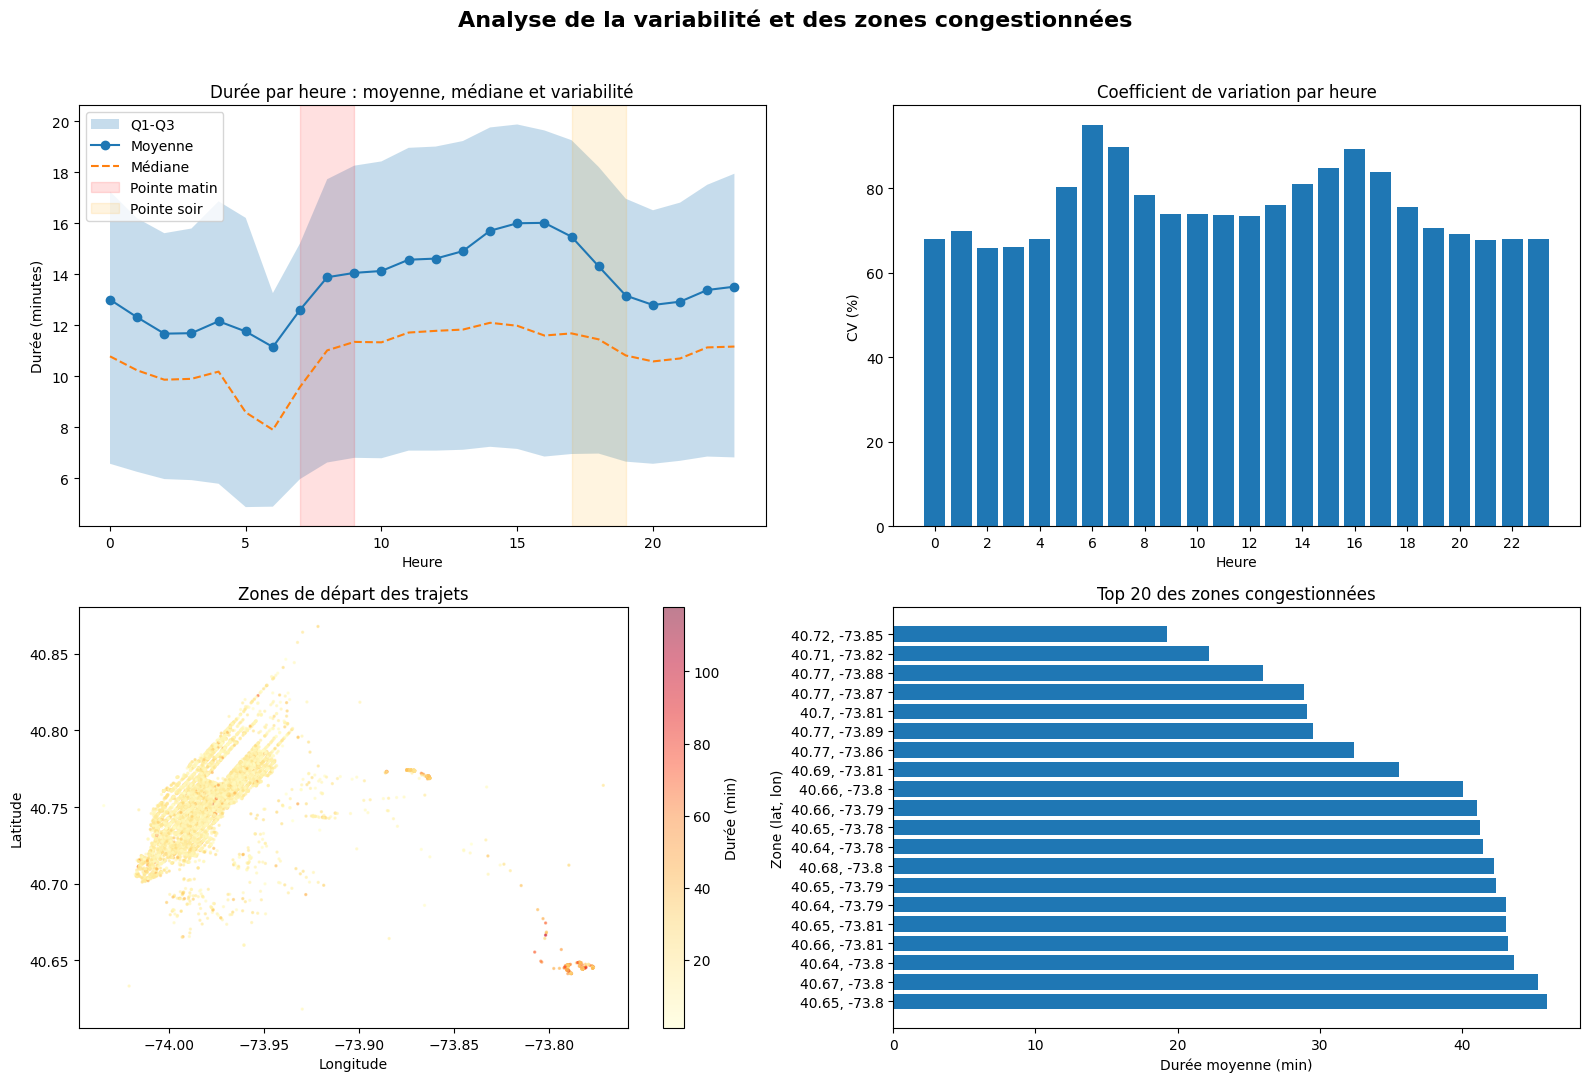

In [20]:
fig, axes = plt.subplots(2, 2, figsize=(16, 11))
fig.suptitle("Analyse de la variabilité et des zones congestionnées", fontsize=16, fontweight='bold')

# 1. Moyenne, médiane et variabilité par heure
hourly = df.groupby('hour')['duration_min'].agg([
    'mean',
    'median',
    lambda x: x.quantile(0.25),
    lambda x: x.quantile(0.75)
])

hourly.columns = ['mean', 'median', 'q25', 'q75']

axes[0, 0].fill_between(hourly.index, hourly['q25'], hourly['q75'], alpha=0.25, label='Q1-Q3')
axes[0, 0].plot(hourly.index, hourly['mean'], marker='o', label='Moyenne')
axes[0, 0].plot(hourly.index, hourly['median'], linestyle='--', label='Médiane')
axes[0, 0].axvspan(7, 9, alpha=0.12, color='red', label='Pointe matin')
axes[0, 0].axvspan(17, 19, alpha=0.12, color='orange', label='Pointe soir')
axes[0, 0].set_title('Durée par heure : moyenne, médiane et variabilité')
axes[0, 0].set_xlabel('Heure')
axes[0, 0].set_ylabel('Durée (minutes)')
axes[0, 0].legend()

# 2. Coefficient de variation par heure
hourly_cv = df.groupby('hour')['duration_min'].agg(['std', 'mean'])
hourly_cv['cv'] = (hourly_cv['std'] / hourly_cv['mean']) * 100

axes[0, 1].bar(hourly_cv.index, hourly_cv['cv'])
axes[0, 1].set_title('Coefficient de variation par heure')
axes[0, 1].set_xlabel('Heure')
axes[0, 1].set_ylabel('CV (%)')
axes[0, 1].set_xticks(range(0, 24, 2))

# 3. Zones de départ des trajets
sample_map = df.sample(10000, random_state=42)

scatter = axes[1, 0].scatter(
    sample_map['pickup_longitude'],
    sample_map['pickup_latitude'],
    c=sample_map['duration_min'],
    cmap='YlOrRd',
    s=2,
    alpha=0.5
)
axes[1, 0].set_title('Zones de départ des trajets')
axes[1, 0].set_xlabel('Longitude')
axes[1, 0].set_ylabel('Latitude')

cbar = fig.colorbar(scatter, ax=axes[1, 0])
cbar.set_label('Durée (min)')

# 4. Top zones congestionnées sous forme de barplot
df['lat_grid'] = (df['pickup_latitude'] * 100).round() / 100
df['lon_grid'] = (df['pickup_longitude'] * 100).round() / 100

zone_stats = df.groupby(['lat_grid', 'lon_grid']).agg(
    duration_mean=('duration_min', 'mean'),
    count=('duration_min', 'count')
).reset_index()

zone_stats = zone_stats[zone_stats['count'] > 50].nlargest(20, 'duration_mean')

zone_labels = zone_stats['lat_grid'].astype(str) + ", " + zone_stats['lon_grid'].astype(str)

axes[1, 1].barh(zone_labels, zone_stats['duration_mean'])
axes[1, 1].set_title('Top 20 des zones congestionnées')
axes[1, 1].set_xlabel('Durée moyenne (min)')
axes[1, 1].set_ylabel('Zone (lat, lon)')

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

# **PARTIE 8- Interprétation**

In [21]:
peak_am = df[df['hour'].between(7, 9)]['duration_min'].mean()
peak_pm = df[df['hour'].between(17, 19)]['duration_min'].mean()
night = df[df['hour'].between(0, 5)]['duration_min'].mean()

max_var_h = hourly_cv['cv'].idxmax()
max_var_v = hourly_cv['cv'].max()

top_zone = zone_stats.iloc[0]

print("Conclusion")
print()

print("1. Quelles sont les heures de pointe ?")
print(f"Les heures de pointe sont surtout le matin entre 7h et 9h ({peak_am:.2f} min)")
print(f"et le soir entre 17h et 19h ({peak_pm:.2f} min).")
print(f"La nuit, la durée moyenne descend à {night:.2f} min.")
print()

print("2. Quelle est la variabilité des temps de trajet ?")
print(f"La variabilité maximale est observée à {max_var_h}h avec un CV de {max_var_v:.2f}%.")
print("Cela montre que les temps de trajet changent selon l’heure.")
print()

print("3. Certaines zones sont-elles plus congestionnées ?")
print("Oui, certaines zones sont plus lentes que d’autres.")
print(f"La zone la plus congestionnée repérée se situe autour de ({top_zone['lat_grid']}, {top_zone['lon_grid']})")
print(f"avec une durée moyenne de {top_zone['duration_mean']:.2f} minutes.")
print()

print("4. Réponse à la problématique")
if p_value < 0.05:
    print("Le test ANOVA confirme que les temps de trajet varient significativement selon les périodes de la journée.")
else:
    print("Le test ANOVA ne montre pas de différence significative.")

Conclusion

1. Quelles sont les heures de pointe ?
Les heures de pointe sont surtout le matin entre 7h et 9h (13.58 min)
et le soir entre 17h et 19h (14.26 min).
La nuit, la durée moyenne descend à 12.29 min.

2. Quelle est la variabilité des temps de trajet ?
La variabilité maximale est observée à 6h avec un CV de 94.88%.
Cela montre que les temps de trajet changent selon l’heure.

3. Certaines zones sont-elles plus congestionnées ?
Oui, certaines zones sont plus lentes que d’autres.
La zone la plus congestionnée repérée se situe autour de (40.65, -73.8)
avec une durée moyenne de 45.98 minutes.

4. Réponse à la problématique
Le test ANOVA confirme que les temps de trajet varient significativement selon les périodes de la journée.


#création la mémoire à partir de tes cellules précédentes

In [22]:
analysis_memory = {}

# Infos générales
analysis_memory["dataset_shape"] = list(df.shape)
analysis_memory["columns"] = list(df.columns)

# Nettoyage
analysis_memory["cleaning"] = {
    "dropna_columns": cols_essentielles,
    "duplicates_removed": True,
    "trip_duration_seconds_range": [60, 7200],
    "pickup_longitude_range": [-74.05, -73.75],
    "pickup_latitude_range": [40.60, 40.90],
    "dropoff_longitude_range": [-74.05, -73.75],
    "dropoff_latitude_range": [40.60, 40.90],
    "passenger_count_range": [1, 6],
    "speed_kmh_range": [0, 120]
}

# Feature engineering
analysis_memory["features_created"] = [
    "hour", "day_of_week", "day_name", "month", "is_weekend",
    "period", "distance_km", "duration_min", "speed_kmh",
    "lat_grid", "lon_grid"
]

analysis_memory["period_definition"] = {
    "Nuit": "0-5",
    "Matin": "6-8",
    "Matinée": "9-11",
    "Midi": "12-13",
    "Après-midi": "14-16",
    "Soirée": "17-19",
    "Nuit tardive": "20-23"
}

# Résumé dataset compact
analysis_memory["dataset_summary"] = {
    "missing_values_after_cleaning": df.isnull().sum().to_dict(),
    "duration_mean_min": round(float(df["duration_min"].mean()), 3),
    "duration_median_min": round(float(df["duration_min"].median()), 3),
    "duration_std_min": round(float(df["duration_min"].std()), 3),
    "distance_mean_km": round(float(df["distance_km"].mean()), 3),
    "speed_mean_kmh": round(float(df["speed_kmh"].mean()), 3)
}

# EDA
analysis_memory["eda"] = {
    "top_5_hours_by_trip_count": dict(hourly_counts.sort_values(ascending=False).head(5)),
    "top_5_hours_by_mean_duration": {int(k): round(float(v), 3) for k, v in hourly_mean.sort_values(ascending=False).head(5).to_dict().items()}
}

# Tests statistiques
analysis_memory["stats_tests"] = {
    "anova": {
        "f_stat": round(float(f_stat), 4),
        "p_value": float(p_value),
        "significant_5pct": bool(p_value < 0.05)
    },
    "eta_squared": round(float(eta2), 4),
    "kruskal": {
        "h_stat": round(float(h_stat), 4),
        "p_value": float(p_kw),
        "significant_5pct": bool(p_kw < 0.05)
    }
}

# Variabilité
analysis_memory["variability"] = {
    "max_variability_hour": int(max_var_h),
    "max_variability_cv": round(float(max_var_v), 3)
}

# Congestion
analysis_memory["congestion"] = {
    "top_zone": {
        "lat_grid": float(top_zone["lat_grid"]),
        "lon_grid": float(top_zone["lon_grid"]),
        "duration_mean": round(float(top_zone["duration_mean"]), 3)
    }
}

# Conclusion
analysis_memory["final_conclusion"] = {
    "peak_am_7_9_mean_min": round(float(peak_am), 3),
    "peak_pm_17_19_mean_min": round(float(peak_pm), 3),
    "night_0_5_mean_min": round(float(night), 3),
    "problematic_answer": (
        "Le test ANOVA confirme que les temps de trajet varient significativement selon les périodes de la journée."
        if p_value < 0.05
        else
        "Le test ANOVA ne montre pas de différence significative."
    )
}

print("analysis_memory prête")
print(analysis_memory.keys())

analysis_memory prête
dict_keys(['dataset_shape', 'columns', 'cleaning', 'features_created', 'period_definition', 'dataset_summary', 'eda', 'stats_tests', 'variability', 'congestion', 'final_conclusion'])


#contexte compact pour le chatbot

In [23]:
previous_cells_context = f"""
Projet : Analyse des temps de trajet NYC Taxi

Dataset final :
- Dimensions : {analysis_memory["dataset_shape"]}
- Colonnes principales : {analysis_memory["columns"][:20]}

Nettoyage :
- Valeurs manquantes supprimées sur : {analysis_memory["cleaning"]["dropna_columns"]}
- Doublons supprimés
- trip_duration filtré entre 60 et 7200 secondes
- passenger_count entre 1 et 6
- speed_kmh entre 0 et 120
- filtre géographique appliqué sur pickup et dropoff

Features créées :
{analysis_memory["features_created"]}

Résultats statistiques :
- ANOVA p-value : {analysis_memory["stats_tests"]["anova"]["p_value"]}
- ANOVA significative : {analysis_memory["stats_tests"]["anova"]["significant_5pct"]}
- Eta carré : {analysis_memory["stats_tests"]["eta_squared"]}
- Kruskal p-value : {analysis_memory["stats_tests"]["kruskal"]["p_value"]}

Heures de pointe :
- 7h-9h : {analysis_memory["final_conclusion"]["peak_am_7_9_mean_min"]} min
- 17h-19h : {analysis_memory["final_conclusion"]["peak_pm_17_19_mean_min"]} min
- 0h-5h : {analysis_memory["final_conclusion"]["night_0_5_mean_min"]} min

Variabilité :
- Heure la plus variable : {analysis_memory["variability"]["max_variability_hour"]}h
- CV max : {analysis_memory["variability"]["max_variability_cv"]} %

Congestion :
- Zone la plus congestionnée : ({analysis_memory["congestion"]["top_zone"]["lat_grid"]}, {analysis_memory["congestion"]["top_zone"]["lon_grid"]})
- Durée moyenne : {analysis_memory["congestion"]["top_zone"]["duration_mean"]} min

Conclusion :
- {analysis_memory["final_conclusion"]["problematic_answer"]}
"""

print(previous_cells_context)


Projet : Analyse des temps de trajet NYC Taxi

Dataset final :
- Dimensions : [1436828, 22]
- Colonnes principales : ['id', 'vendor_id', 'pickup_datetime', 'dropoff_datetime', 'passenger_count', 'pickup_longitude', 'pickup_latitude', 'dropoff_longitude', 'dropoff_latitude', 'store_and_fwd_flag', 'trip_duration', 'hour', 'day_of_week', 'day_name', 'month', 'is_weekend', 'period', 'distance_km', 'duration_min', 'speed_kmh']

Nettoyage :
- Valeurs manquantes supprimées sur : ['pickup_datetime', 'dropoff_datetime', 'trip_duration', 'pickup_longitude', 'pickup_latitude', 'dropoff_longitude', 'dropoff_latitude', 'passenger_count']
- Doublons supprimés
- trip_duration filtré entre 60 et 7200 secondes
- passenger_count entre 1 et 6
- speed_kmh entre 0 et 120
- filtre géographique appliqué sur pickup et dropoff

Features créées :
['hour', 'day_of_week', 'day_name', 'month', 'is_weekend', 'period', 'distance_km', 'duration_min', 'speed_kmh', 'lat_grid', 'lon_grid']

Résultats statistiques :
- A

#chatbot

In [24]:
# Mémoire courte pour ne pas trop consommer
chat_memory = []

def chat_with_dataset(message, history):
    global chat_memory

    # On garde seulement les 4 derniers échanges
    short_history = history[-4:] if history else []

    history_text = ""
    for user_msg, bot_msg in short_history:
        history_text += f"Utilisateur: {user_msg}\nAssistant: {bot_msg}\n"

    # Petit aperçu du dataframe seulement
    df_preview = df.head(5).to_csv(index=False)

    prompt = f"""
Tu es un assistant d'analyse de données.
Tu dois répondre seulement à partir :
1. du dataframe df déjà chargé
2. du contexte des cellules précédentes
3. de l'historique récent

Règles :
- Réponds en français
- Réponse claire, simple, pas trop longue
- N'invente jamais une valeur
- Si l'information n'est pas disponible, dis-le clairement
- Priorité au contexte des cellules précédentes
- Si la question porte sur la conclusion, les tests, la variabilité, les heures de pointe ou la congestion, utilise d'abord le contexte mémoire
- Si la question porte sur une colonne ou une structure du dataset, utilise le résumé du dataframe
- N'affiche pas de longues listes inutiles

Contexte cellules précédentes :
{previous_cells_context}

Aperçu du dataframe :
{df_preview}

Historique récent :
{history_text}

Question utilisateur :
{message}
"""

    try:
        response = client.responses.create(
            model="gpt-4.1-nano",
            input=prompt
        )
        return response.output_text
    except Exception as e:
        txt = str(e)
        if "insufficient_quota" in txt:
            return "Erreur : quota API insuffisant."
        return f"Erreur : {txt}"

#interface finale du chatbot

In [ ]:
demo = gr.ChatInterface(
    fn=chat_with_dataset,
    title="Chatbot Dataset + Cellules précédentes",
    description="Pose des questions sur le dataset et sur les analyses déjà faites"
)

demo.launch(debug=True, share=True)

Colab notebook detected. This cell will run indefinitely so that you can see errors and logs. To turn off, set debug=False in launch().
* Running on public URL: https://6b1dc0ec6f4022a478.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
